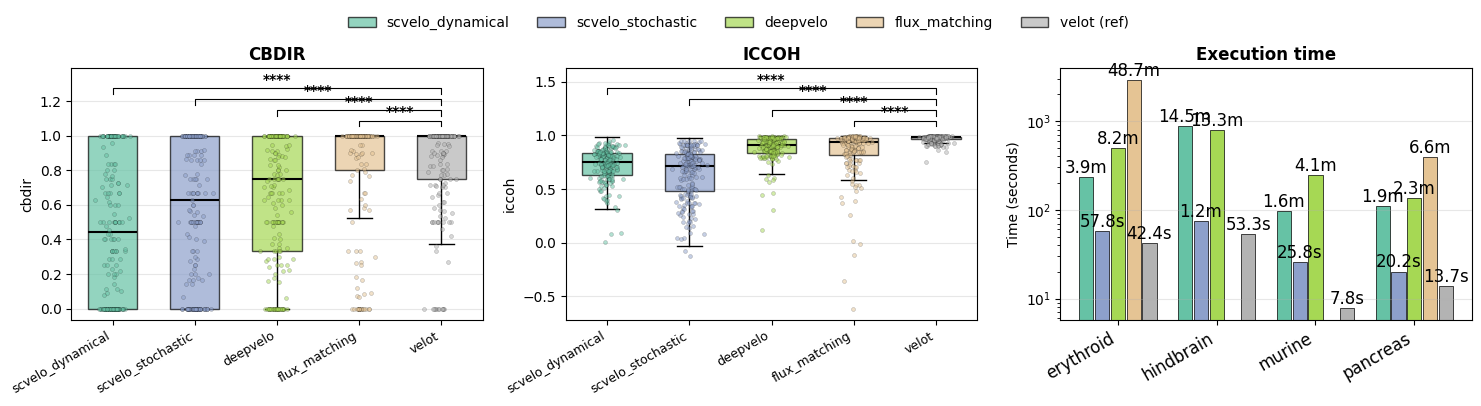

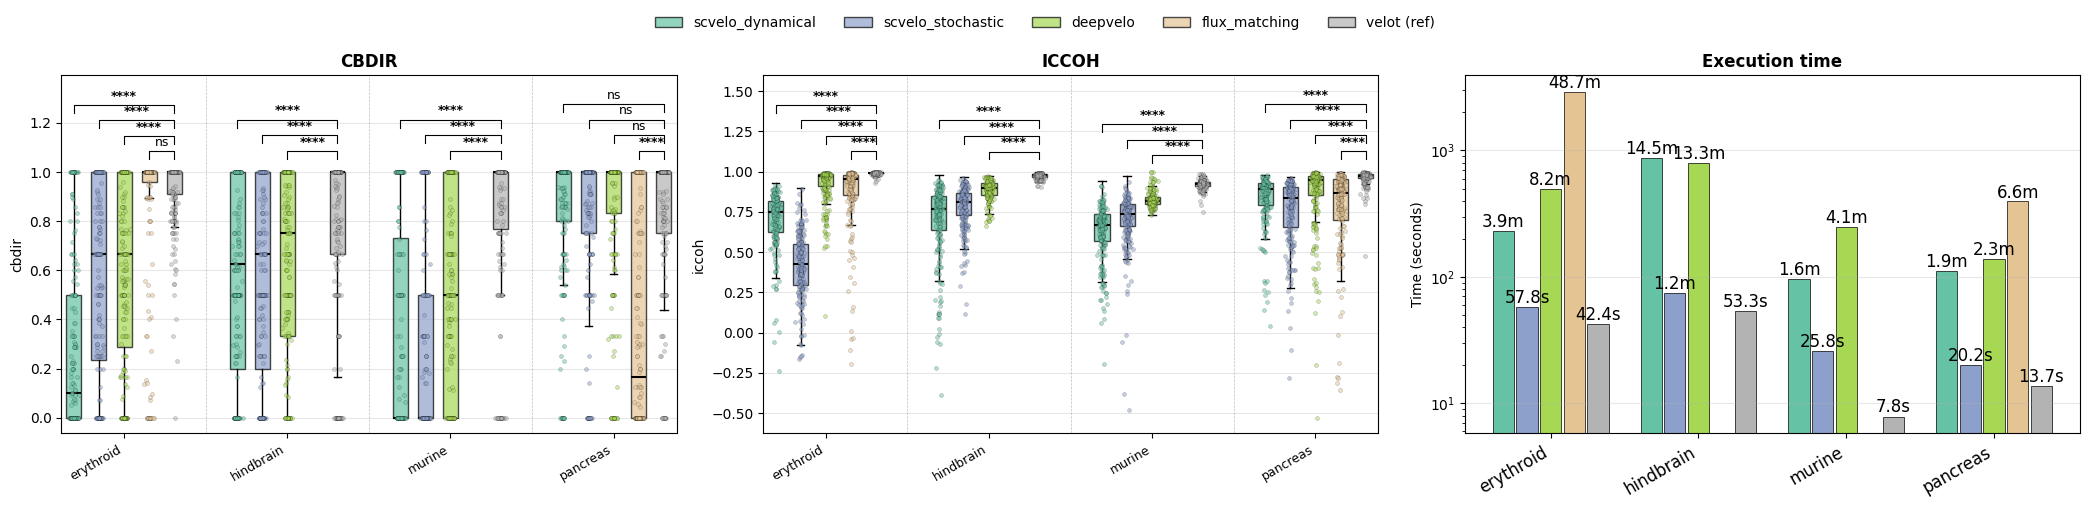

In [6]:
from velot.pl2 import benchmark_comparison

# Default: simple overview
benchmark_comparison("benchmark_results/real", models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"])

# Per dataset: compare models within each dataset
benchmark_comparison(
    "benchmark_results/real",
    detail="per_dataset",
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"], figsize_per_panel=(7,5)
);

# Full detail: every edge/cluster visible
# benchmark_comparison(
#     "benchmark_results",
#     detail="per_group",
#     figsize_per_panel=(7, 6),  # wider panels for many groups
#     models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"]
# );

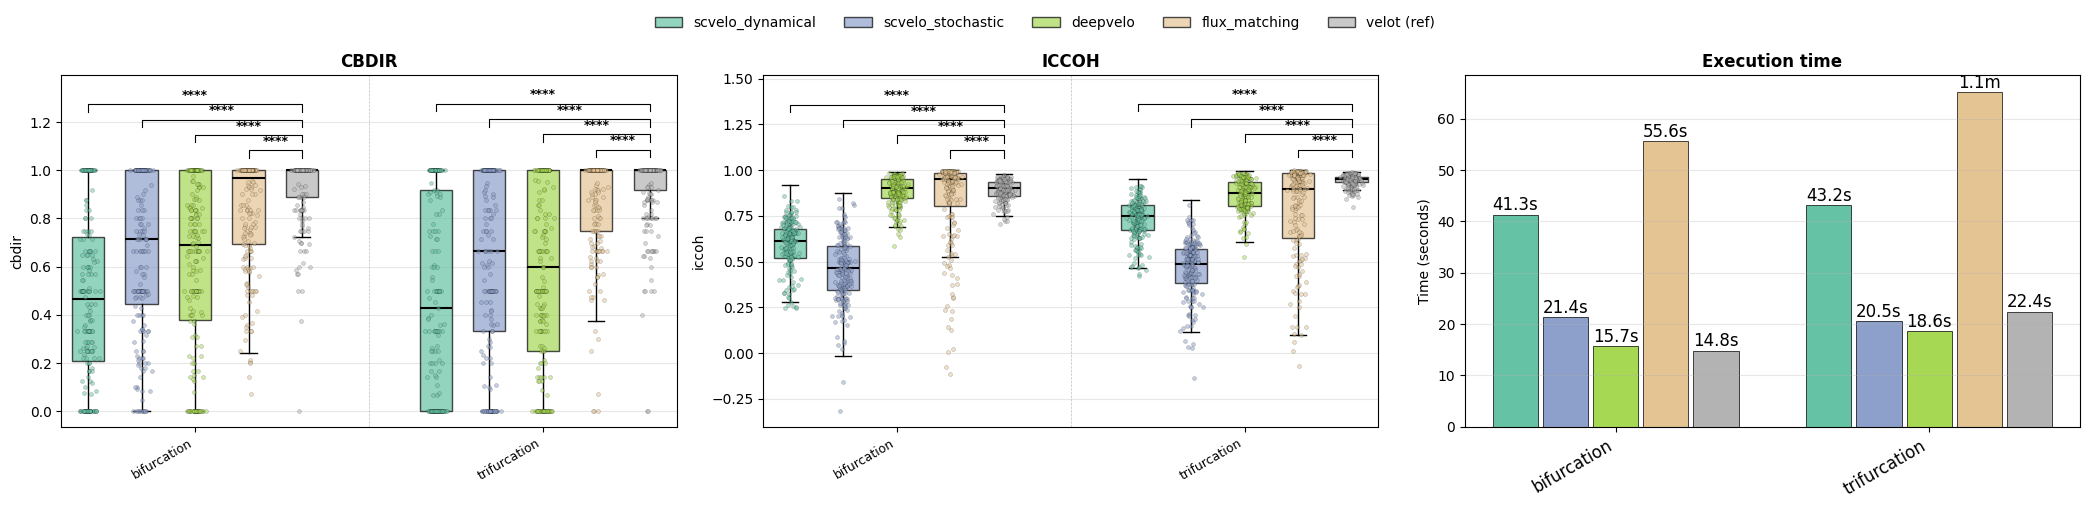

In [9]:
from velot.pl2 import benchmark_comparison

# Per dataset: compare models within each dataset
benchmark_comparison(
    "benchmark_results/synthetic",
    detail="per_dataset",
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"], figsize_per_panel=(7,5)
);

/home/user/miniforge3/envs/velot/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


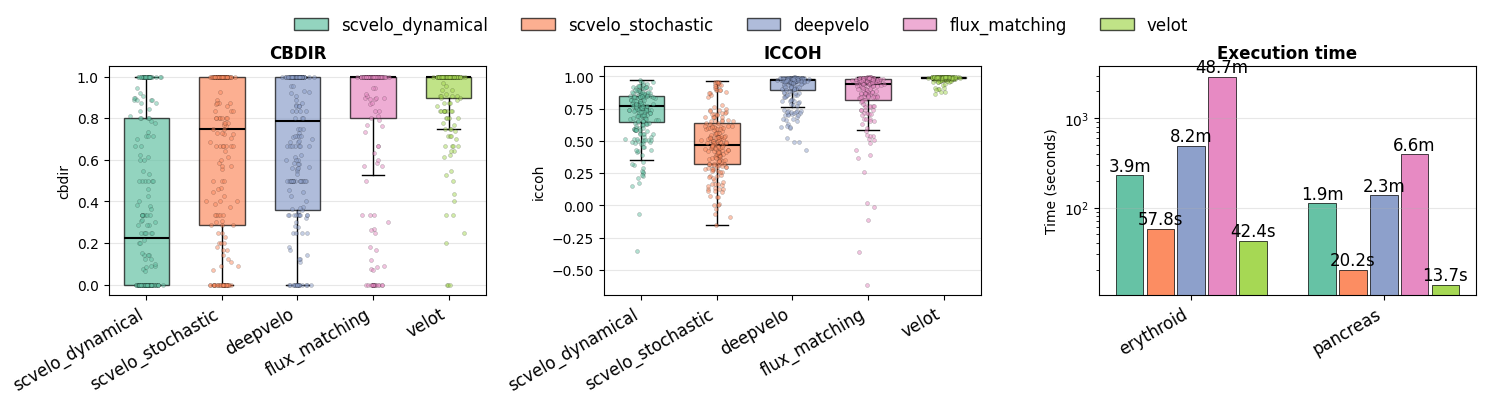

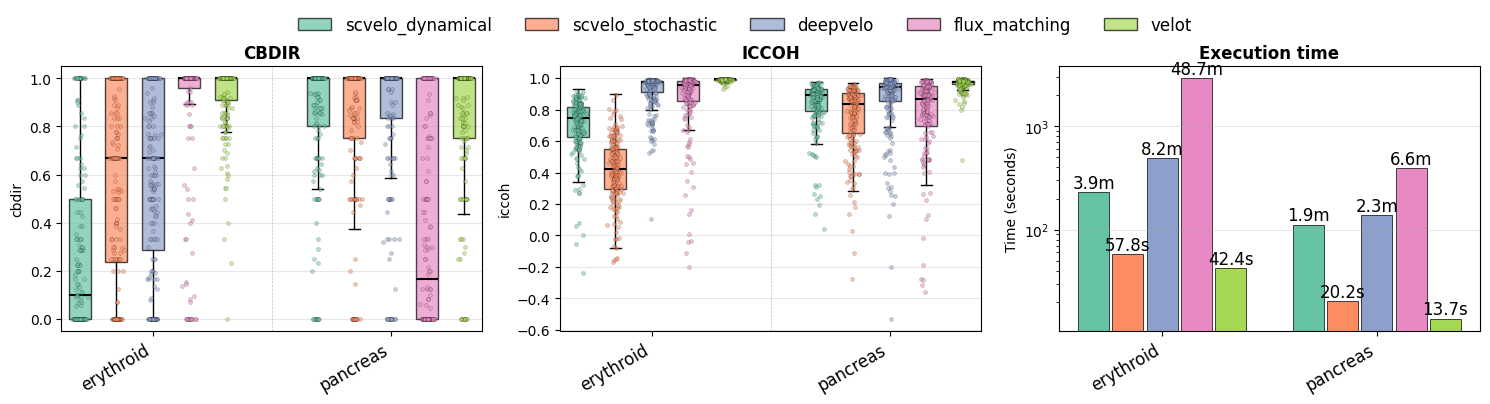

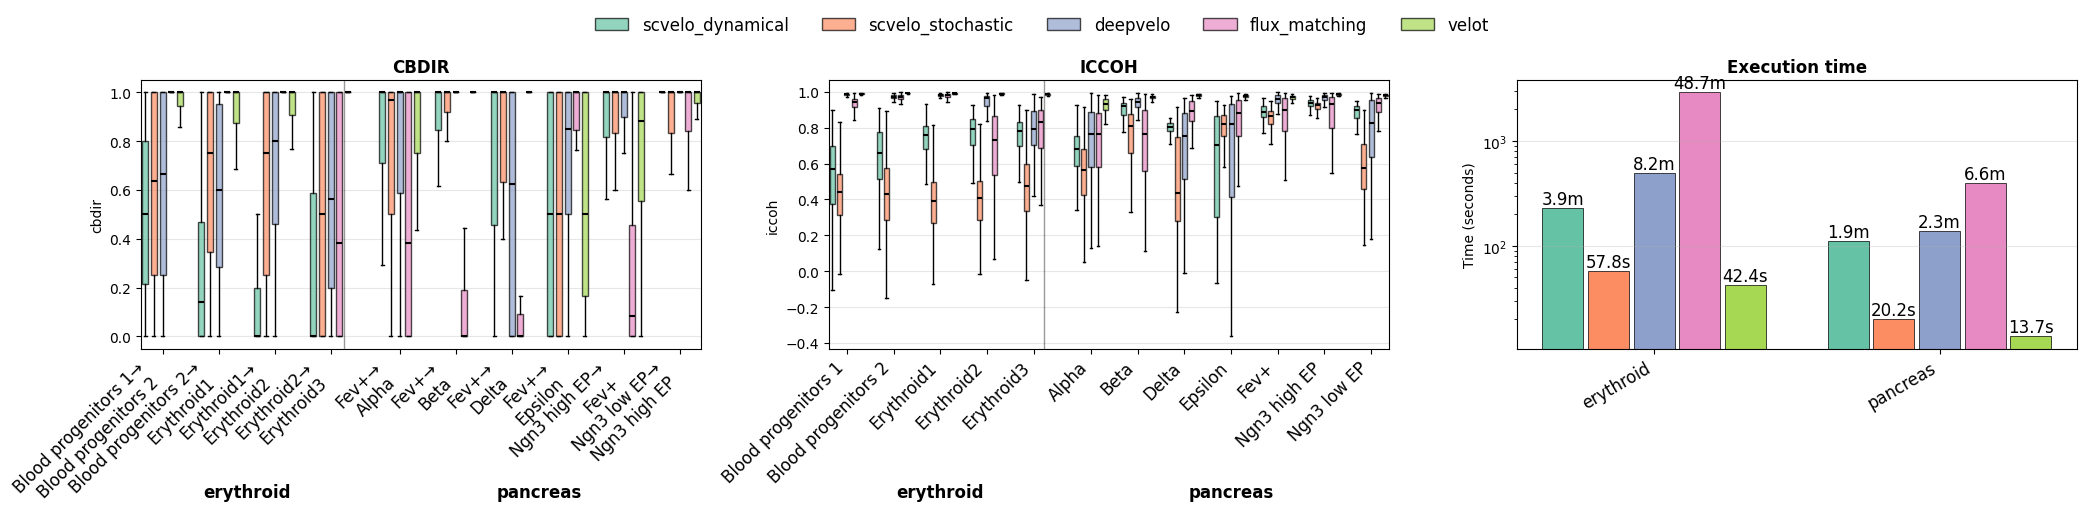

In [1]:
from velot.benchmark import load_benchmarks, load_benchmarks_per_group
from velot.pl import benchmark_comparison

# Default: simple overview
benchmark_comparison("benchmark_results", models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"])

# Per dataset: compare models within each dataset
benchmark_comparison(
    "benchmark_results",
    detail="per_dataset",
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"]
)

# Full detail: every edge/cluster visible
benchmark_comparison(
    "benchmark_results",
    detail="per_group",
    figsize_per_panel=(7, 6),  # wider panels for many groups
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"]
);

In [1]:
import velot
import scanpy as sc

/home/user/miniforge3/envs/velot/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
adata = sc.read_h5ad("/home/user/Documents/velot/article/datasets/pancreas_velot.h5ad")
edges = [
    ('Ngn3 low EP', 'Ngn3 high EP'), 
    ('Ngn3 high EP', 'Fev+'),
    ('Fev+', 'Delta'), 
    ('Fev+', 'Beta'),
    ('Fev+','Epsilon'),
    ('Fev+','Alpha')
]

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.967):
                      Alpha: 0.923
                       Beta: 0.966
                      Delta: 0.980
                    Epsilon: 0.973
                       Fev+: 0.964
               Ngn3 high EP: 0.986
                Ngn3 low EP: 0.979

Cross-Boundary Correctness (mean: 0.814):
      Ngn3 low EP → Ngn3 high EP   : 0.935
     Ngn3 high EP → Fev+           : 0.736
             Fev+ → Delta          : 0.857
             Fev+ → Beta           : 0.968
             Fev+ → Epsilon        : 0.550
             Fev+ → Alpha          : 0.837


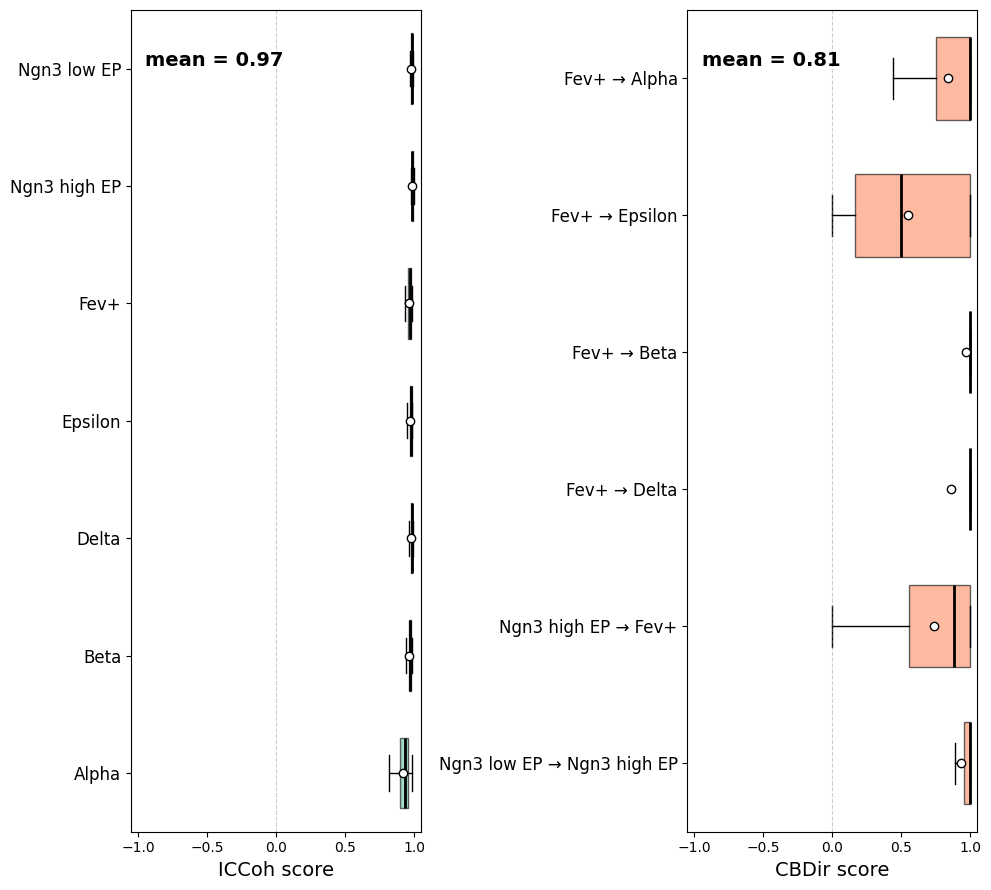

In [3]:
results = velot.metrics.summary(adata, cluster_edges=edges, cluster_key="clusters", embedding_key=f"X_pca", velocity_key=f"velot_velocity_pca")
velot.pl.metric_summary(results, orientation="horizontal", layout="row", figsize=(10,9), show=True, save=False)

In [ ]:
results

dict_keys(['iccoh', 'iccoh_mean', 'iccoh_median', 'cbdir', 'cbdir_mean', 'cbdir_median'])

In [2]:
adata = sc.read_h5ad("/home/user/Documents/velot/article/data/HindBrain/Hindbrain_GABA_Glio.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 13501 × 55421
    obs: 'TotalUMIs', 'barcode', 'Celltype', 'Lineage', 'Timepoint'
    var: 'Accession', 'AccessionVersion', 'Aliases', 'CcdsID', 'Chromosome', 'ChromosomeEnd', 'ChromosomeStart', 'CosmicID', 'DnaBindingDomain', 'FullName', 'GeneType', 'HgncID', 'IsTFi (TcoF-DB)', 'Location', 'LocationSortable', 'LocusGroup', 'LocusType', 'MgdID', 'MirBaseID', 'OmimID', 'PubmedID', 'RefseqID', 'Regulates (TRRUST)', 'RgdID', 'Strand', 'UcscID', 'UniprotID', 'VegaID'
    obsm: 'X_tsne'
    layers: 'matrix', 'spliced', 'unspliced'

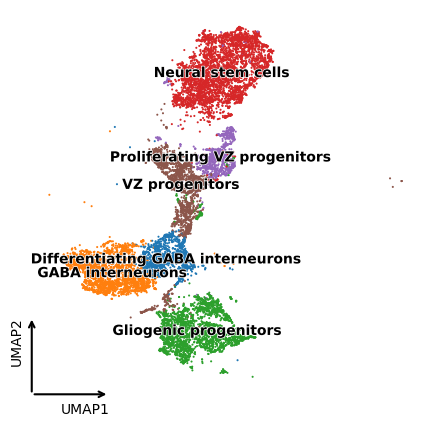

In [5]:
velot.pl.dataset_overview_simple(adata, "Celltype", "tsne", "", False, False, inframe=True)

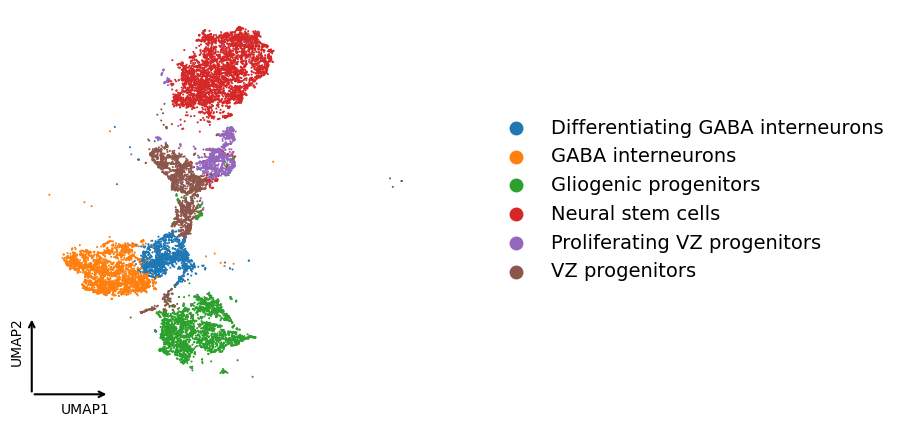

In [6]:
velot.pl.dataset_overview_simple(adata, "Celltype", "tsne", "", False, False, inframe=False)

In [ ]:

gaba_edges = [('Neural stem cells', 'progenitors'), ('Proliferating VZ progenitors', 'VZ progenitors'),
                         ('VZ progenitors', 'Gliogenic progenitors'), 
                          ('VZ progenitors', 'Differentiating GABA interneurons'),
                         ('Differentiating GABA interneurons', 'GABA interneurons')]

In [10]:
sc.pp.pca(adata, 50)

In [12]:
sc.pp.neighbors(adata, 15, use_rep="X_pca")

In [13]:
sc.tl.umap(adata)

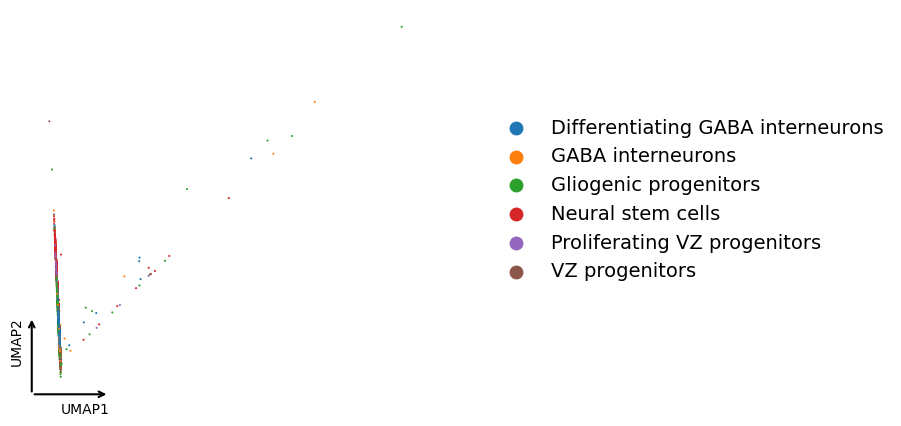

In [14]:
velot.pl.dataset_overview_simple(adata, "Celltype", basis="pca")

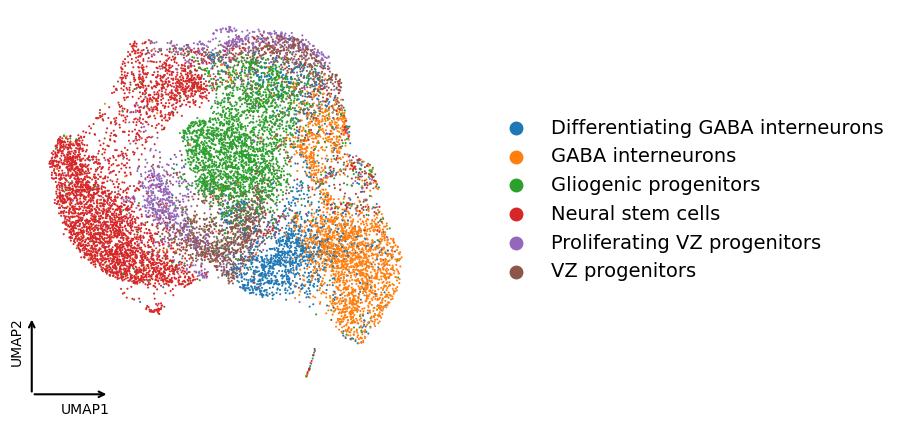

In [16]:
velot.pl.dataset_overview_simple(adata, "Celltype", basis="umap")